In [ ]:

import os
import gzip
import numpy as np

In [7]:
def load_mnist(path, kind='train'):
    """Load MNIST data from `path`"""
    
    # Define paths to labels and images files
    labels_path = os.path.join(path, '%s-labels-idx1-ubyte.gz' % kind)
    images_path = os.path.join(path, '%s-images-idx3-ubyte.gz' % kind)

    # Load labels
    with gzip.open(labels_path, 'rb') as lbpath:
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8, offset=8)

    # Load images
    with gzip.open(images_path, 'rb') as imgpath:
        images = np.frombuffer(imgpath.read(), dtype=np.uint8, offset=16).reshape(len(labels), 784)

    return images, labels

In [9]:
folder = "/".join([os.path.expanduser("~/"), "Workspace/repos/fashion-mnist/data/fashion"])
train_images, train_labels = load_mnist(folder)
len(train_images), len(train_labels)

(60000, 60000)

In [116]:
MEAN = np.array(train_images).mean()
STD = np.array(train_images).std()

In [11]:
image = train_images[0]
np.sqrt(image.shape[0])

28.0

In [115]:
%matplotlib inline
import matplotlib.pyplot as plt
import cv2
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import v2

In [117]:
transforms = v2.Compose([
    # v2.RandomResizedCrop(size=(224, 224), antialias=True),
    # v2.RandomHorizontalFlip(p=0.5),
    # v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[MEAN], std=[STD]),
])

In [118]:
def preprocess(x, size_final=32):

    n = int(math.sqrt(x.shape[0]))
    x = x.reshape((n, n, -1))

    x = cv2.resize(x, (size_final, size_final), interpolation=cv2.INTER_LINEAR)
    if len(x.shape) == 2:
        x = x[..., np.newaxis]
    x = np.transpose(x, (2, 0, 1))

    x = torch.tensor(x[np.newaxis, ...], dtype=torch.float32)

    x = transforms(x)

    return x

In [119]:
class ConvBlock(torch.nn.Module):

    def __init__(self, **kwargs):

        super().__init__()

        input_channel = kwargs.get("input_channel", 3)
        output_channel = kwargs.get("output_channel", 3)
        kernel_size = kwargs.get("kernel_size", 3)

        self.conv = nn.Conv2d(
            in_channels=input_channel,
            out_channels=output_channel,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            stride=2
        )
        self.dropout = nn.Dropout()
        self.norm = nn.BatchNorm2d(output_channel)
        self.activate = nn.ReLU()

    def forward(self, x):

        x = self.conv(x)
        x = self.dropout(x)
        x = self.norm(x)
        x = self.activate(x)

        return x


class Discriminator(torch.nn.Module):

    def __init__(self, **kwargs):

        super().__init__()
        channels = kwargs.get("channels", [3, 5])
        channels = [
            {"input_channel": x, "output_channel": y}
            for x, y in zip([1] + channels[:-1], channels)
        ]

        self.conv_blocks = nn.Sequential(
            *[
                ConvBlock(
                    input_channel=channel_config["input_channel"],
                    output_channel=channel_config["output_channel"],
                    **kwargs
                )
                for channel_config in channels
            ]
        )

        self.pooling = nn.AdaptiveAvgPool2d(1)

        dummy_input = torch.ones(1, 1, 32, 32)
        with torch.no_grad():
            feat = self.conv_blocks(dummy_input).shape[1]

        self.classification = nn.Linear(in_features=feat, out_features=1)
        self.activate = nn.ReLU()
        self.decision = nn.Sigmoid()

    def forward(self, x):

        x = self.conv_blocks(x)
        x = self.pooling(x)
        x = self.classification(x)
        x = self.activate(x)
        return self.decision(x)


In [ ]:
class ConvUpBlock(torch.nn.Module):

    def __init__(self, **kwargs):

        super().__init__()

        input_channel = kwargs.get("input_channel", 3)
        output_channel = kwargs.get("output_channel", 3)
        kernel_size = kwargs.get("kernel_size", 4)
        self.conv_transpose = nn.ConvTranspose2d(
            in_channels=input_channel,
            out_channels=output_channel,
            kernel_size=kernel_size,
            padding=1,
            stride=2,
        )
        self.dropout = nn.Dropout()
        self.norm = nn.BatchNorm2d(output_channel)
        self.activate = nn.ReLU()

    def forward(self, x):

        x = self.conv_transpose(x)
        x = self.dropout(x)
        x = self.norm(x)
        x = self.activate(x)
        return x


class Generator(nn.Module):

    def __init__(self, **kwargs):

        super().__init__()
        channels = kwargs.get("channels", [32, 16, 8, 4, 2, 1])

        channels = [
            {"input_channel": x, "output_channel": y}
            for x, y in zip(channels[:-1], channels[1:])
        ]
        self.conv_transpose_blocks = nn.Sequential(
            *[
                ConvUpBlock(
                    input_channel=channel_config["input_channel"],
                    output_channel=channel_config["output_channel"],
                    **kwargs
                )
                for channel_config in channels
            ]
        )

        self.decision = nn.Tanh()

    def forward(self, x):
        x = self.conv_transpose_blocks(x)
        return self.decision(x)


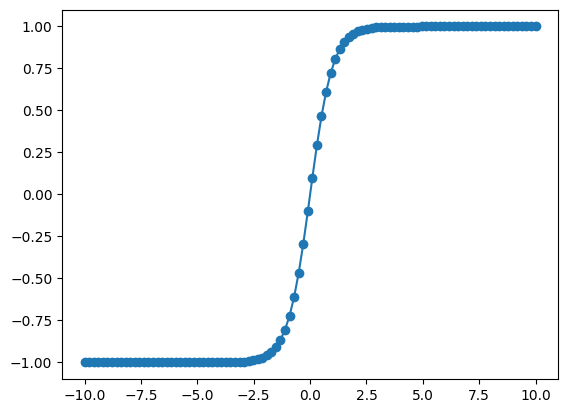

In [109]:
x = torch.linspace(-10, 10, 100)
y = F.tanh(x)
plt.plot(x, y, marker="o")
plt.show()

In [ ]:
nn.Tanh()

In [101]:
D = Discriminator()
G = Generator()

In [104]:
x = torch.rand((1, 32, 1, 1))
G(x).shape

torch.Size([1, 1, 32, 32])

In [28]:
train_images[0].shape

(784,)

In [47]:
x = preprocess(train_images[0])
conv = nn.Conv2d(1, 1, 3, padding=1, stride=2)
for _ in range(2):
    x = conv(x)
    print(x.shape)

torch.Size([1, 1, 16, 16])
torch.Size([1, 1, 8, 8])


In [79]:
conv_trans = nn.ConvTranspose2d(16, 8, 4, stride=2, padding=1)
x = torch.rand((1, 16, 1, 1))
oup = conv_trans(x)
oup.shape

torch.Size([1, 8, 2, 2])

ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 8, 1, 1])